# Analising NiGe XRD data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve

import plotly.graph_objects as go

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
API_KEY = "Nc1dTFzE1dg6gchvs0voTKE07XuuXIKW"


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### read file

In [ ]:
file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Ge\Stückchen\XRD\04272026_B3_richtigrum_exported.xy"
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_9_3_1050C_2min_in-plane_GIXRD_detector_scan.xy"

data = pd.read_csv(file_path, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])
# data = pd.read_csv(file_path, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])

name = os.path.basename(file_path)
# name = filename.split("_", 1)[1].split("grad")[0]
# print(name)

print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Angle      9995 non-null   float64
 1   Intensity  9995 non-null   float64
dtypes: float64(2)
memory usage: 156.3 KB
None


### plot basic spectra starting point

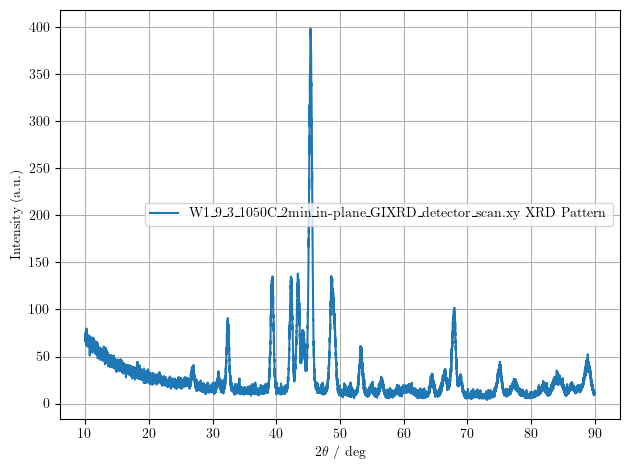

In [25]:
fig, ax = plt.subplots()

ax.plot(data['Angle'], data['Intensity'], label=f'{name} XRD Pattern')

# ax.axes.get_yaxis().set_ticklabels([])
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

In [23]:
# asymmetric least squares baseline correction
def baseline_als(y, lam=1e5, p=0.01, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2), dtype=None)
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w,0,L,L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

In [5]:
test, _ = signal.find_peaks(data['Intensity'], width=5, height=100)
data.loc[test, 'Angle']

4469    65.5838
Name: Angle, dtype: float64

In [12]:
# use a reagion of interest to isolate the SiC peak (64.5 - 66.5)
peak_start, peak_end = 64.5, 66.5
silicide_part = data[data['Angle'] < peak_start].copy()
substrate_part = data[(data['Angle'] >= peak_start) & (data['Angle'] <= peak_end)].copy()
tail_part = data[data['Angle'] > peak_end].copy()

# process silicide part
silicide_part['baseline'] = baseline_als(silicide_part['Intensity'])
silicide_part['corrected'] = silicide_part['Intensity'] - silicide_part['baseline']
silicide_part['filtered'] = signal.savgol_filter(silicide_part['corrected'], 11, 3)

# process tail part
tail_part['baseline'] = baseline_als(tail_part['Intensity'])
tail_part['corrected'] = tail_part['Intensity'] - tail_part['baseline']
tail_part['filtered'] = signal.savgol_filter(tail_part['corrected'], 11, 3)

# normalize everything to the silicides strongest peak
scale_factor = silicide_part['filtered'].max()

silicide_part['intensity_norm'] = silicide_part['filtered'] / scale_factor
substrate_part['intensity_norm'] = substrate_part['Intensity'] / scale_factor # Substrate will be > 1.0
tail_part['intensity_norm'] = tail_part['filtered'] / scale_factor

# find peaks in silicide and tail parts
sil_peaks_idx, _ = signal.find_peaks(silicide_part['filtered'], prominence=0.2 * silicide_part['filtered'].max(), width=5)
sil_actual_indices = silicide_part.index[sil_peaks_idx]
tail_peaks_idx, _ = signal.find_peaks(tail_part['filtered'], prominence=0.2 * silicide_part['filtered'].max(), width=5)
tail_actual_indices = tail_part.index[tail_peaks_idx]

all_peak_indices = np.concatenate([sil_actual_indices, tail_actual_indices])

# combine back together
full_processed = pd.concat([silicide_part, substrate_part, tail_part]).sort_values('Angle')
full_processed['log_intensity'] = np.log10(full_processed['intensity_norm'] + 1)

peak_angles = full_processed.loc[all_peak_indices, 'Angle']
print(peak_angles)

70      20.7140
198     22.0196
651     26.6402
2300    43.4600
2445    44.9390
5388    74.9576
Name: Angle, dtype: float64


C:\Users\lhager\AppData\Local\Temp\ipykernel_13732\4060365311.py:9: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


## data processing
- remove background
- apply filter (Savitzky–Golay)
- normalise
- peak finding

### baseline correction

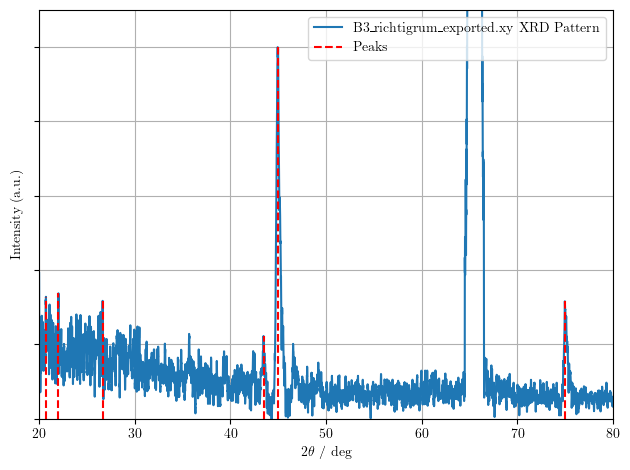

In [13]:
fig, ax = plt.subplots()

ax.plot(full_processed['Angle'], full_processed['intensity_norm'], label=f'{name} XRD Pattern')

plt.vlines(peak_angles.values, ymin=0, ymax=full_processed['intensity_norm'].iloc[all_peak_indices], color='red', linestyle='--', label='Peaks')
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(20, 80)
plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

In [28]:
final_peaks = {
'$Ni_2Si$': [32.8, 39.82, 42.78, 43.92, 45.86, 53.86], # 43.92
'$NiSi$': [31.28, 49.58, 61.78, 66.98, 75.54], 
'$Ni_3Si_2$': [44.74, 77.58],
'$Ni_{31}Si_{12}$': [57.04, 68.44]
# 'Ni': [44.5]   # 77.62
}

|Phase|material_id|shape|  |   |   |   |   |   |  |  |  |  |  |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
|$NiSi_2$|mp-2291   | Cubic | 28.68  |  47.72 | 56.63  | 69.78  | 77.12 |  |  |  |  |  |  |
|$NiSi$|mp-1095177  | Cubic | 27.77  |  34.46 | 40.00  | 44.97  | 49.54 | 61.74 | 65.48 | 69.12 | 76.15 | 79.58 |  |
|$NiSi$|mp-351      | Ortho | 31.33 | 34.87 | 35.97 | 44.53 | 46.01 | 47.57 | 52.35 | 56 | 76.29 | 79.6 |  |
|$Ni_2Si$|mp-1118   | Ortho | 27.25 | 32.85 | 39.87 | 42.83 | 44.12 | 45.94 | 49.25 | 54.07 | 68.86 | 76.14 | 78.78 |
|$Ni_2Si$|mp-507    | hex   | 32.28 | 45.72 | 46.88 | 67.57 | 77.62 |  |  |  |  |  |  |
|$Ni$   |mp-23      | Cubic | 45.15 | 52.63 | 77.65 |  |  |  |  |  |  |  |  |
|$Ni$   |mp-10257   | hex   | 42.61 | 44.45 | 48.36 | 63.27 | 77.99 |  |  |  |  |  |  |

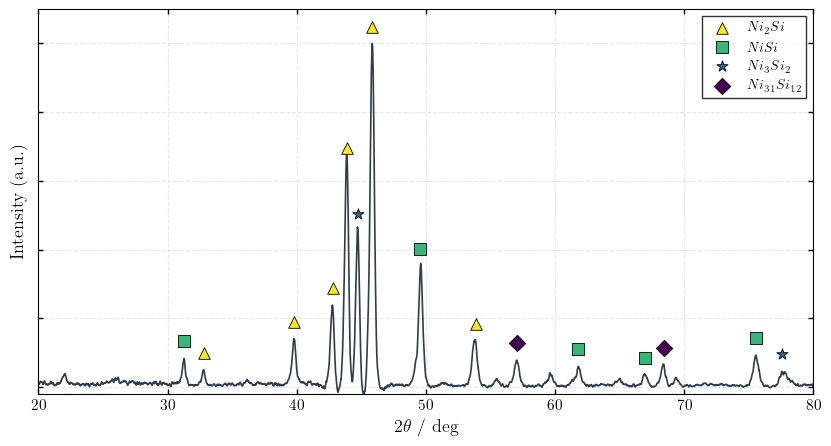

In [ ]:
marker_map = {
    '$NiSi_2$': 'o',  # Circle
    '$NiSi$': 's',   # Square
    '$Ni_2Si$': '^',  # Triangle
    '$Ni_3Si_2$': '*', # Star
    '$Ni_{31}Si_{12}$': 'D'# Diamond
}
# color_map = {
#     'NiSi2': '#00006a', 
#     'NiSi': '#8b0a74',  #8b0a74  7f007b
#     'Ni2Si': '#43a743', 
#     'Ni': '#d8c409'
# }

colors = plt.get_cmap('viridis_r')(np.linspace(0, 1, len(final_peaks)))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(full_processed['Angle'], full_processed['intensity_norm'], color='#2c3e50', lw=1.2, zorder=2)

for lable in final_peaks:
    angles = final_peaks[lable]
    ax.scatter(angles, full_processed[full_processed['Angle'].isin(angles)]['intensity_norm'].values + 0.05, 
                marker=marker_map.get(lable, 'x'),
                color=colors[list(final_peaks.keys()).index(lable) % len(colors)],
                label=lable,
                s=70, edgecolor='black', linewidth=0.6, zorder=5)

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)

ax.set_yticklabels([])
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.1)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)

ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
ax.legend(frameon=True, edgecolor='black', fancybox=False, fontsize=10, loc='upper right')

plt.savefig(f'../Images/XRD/{name}.pdf', dpi=500)
plt.show()